# Importing the Libraries

In [2]:
import pandas as pd
import numpy as np
#For Visualisaton
import matplotlib.pyplot as plt
import seaborn as sns
#For models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_score,
    recall_score,
    f1_score
)
import warnings
warnings.filterwarnings("ignore")

# Data Loading and Exploring

In [3]:
df = pd.read_csv(r"C:\Users\Admin\OneDrive\Documents\Employee_Attrition_Palak bansal\IBM-HR-Employee-Attrition.csv")
df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [4]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 1470
Columns: 35


In [5]:
df["Attrition"].head()

0    Yes
1     No
2    Yes
3     No
4     No
Name: Attrition, dtype: object

In [6]:
df["Attrition"].value_counts()
attrition_rate = (df["Attrition"].value_counts(normalize=True) * 100)
print(attrition_rate)

Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64


*The dataset is imbalanced because the majority of employees stayed with the company, while only a small percentage left.*

In [7]:
numerical = df.select_dtypes(include=["int64","float64"]).columns
categorical = df.select_dtypes(include=["object"]).columns
print("Numerical Columns:", len(numerical))
print("Categorical Columns:", len(categorical))
print(numerical)
print(categorical)

Numerical Columns: 26
Categorical Columns: 9
Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome',
       'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike',
       'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')
Index(['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender',
       'JobRole', 'MaritalStatus', 'Over18', 'OverTime'],
      dtype='object')


# Data Cleaning and Preprocessing

In [8]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

*There are no missing values in the dataset, so no missing value treatment is required.*

In [9]:
df.duplicated().sum()

np.int64(0)

*No duplicate records were found.*

In [10]:
df.drop(columns=[
    'EmployeeNumber',
    'EmployeeCount',
    'Over18',
    'StandardHours'
],inplace=True)

In [11]:
df.columns
df.shape

(1470, 31)

In [12]:
df["Attrition"] = df["Attrition"].map({
    "Yes":1,
    "No":0
})
df["Attrition"].head()

0    1
1    0
2    1
3    0
4    0
Name: Attrition, dtype: int64

# Exploratory Data Analysis (EDA)

In [14]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,3,0,8,3,3,8,7,3,0
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,3,4,1,6,3,3,2,2,2,2


## Attrition Rate by Department

In [15]:
dept_attrition = (df.groupby("Department")["Attrition"]
                  .mean()
                  .sort_values(ascending=False)
                 )
print(dept_attrition)

Department
Sales                     0.206278
Human Resources           0.190476
Research & Development    0.138398
Name: Attrition, dtype: float64


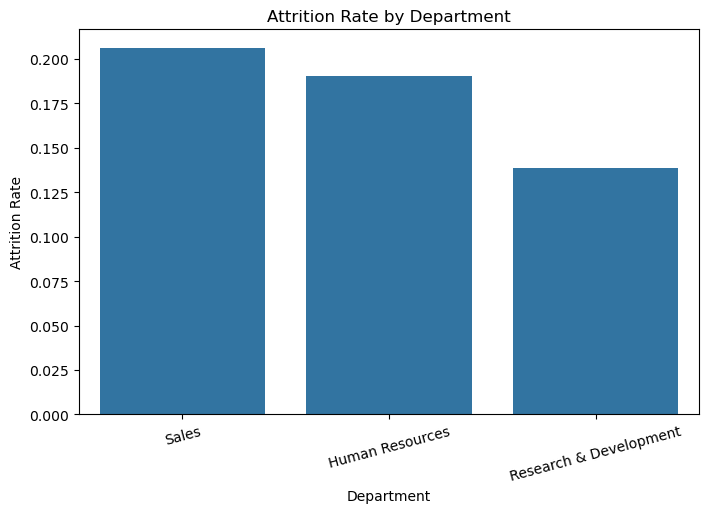

In [16]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=dept_attrition.index,
    y=dept_attrition.values
)

plt.title("Attrition Rate by Department")
plt.ylabel("Attrition Rate")
plt.xlabel("Department")
plt.xticks(rotation=15)

plt.show()

*Sales Department has the highest attrition rate, followed by Human Resources, while Research & Development has the lowest.*

## Attrition Rate by Job Role

In [17]:
job_attrition = (
    df.groupby("JobRole")["Attrition"]
    .mean()
    .sort_values(ascending=False)
)
print(job_attrition)

JobRole
Sales Representative         0.397590
Laboratory Technician        0.239382
Human Resources              0.230769
Sales Executive              0.174847
Research Scientist           0.160959
Manufacturing Director       0.068966
Healthcare Representative    0.068702
Manager                      0.049020
Research Director            0.025000
Name: Attrition, dtype: float64


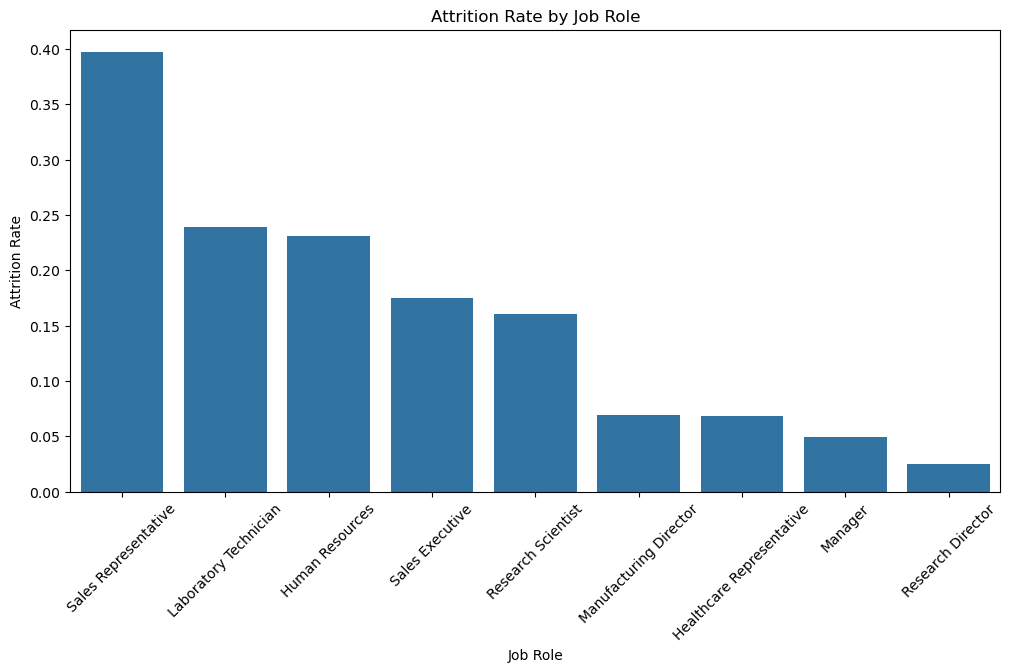

In [18]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=job_attrition.index,
    y=job_attrition.values,
)
sns.set_palette("tab10")
plt.xlabel("Job Role")
plt.ylabel("Attrition Rate")
plt.xticks(rotation=45)
plt.title("Attrition Rate by Job Role")
plt.show()


*Sales Representative and Laboratory Technicians show the highest attrition rates.*

## Attrition vs Monthly Income

MonthlyIncome
1009     1.0
1051     0.0
1052     0.0
1081     1.0
1091     1.0
        ... 
19859    1.0
19926    0.0
19943    0.0
19973    0.0
19999    0.0
Name: Attrition, Length: 1349, dtype: float64


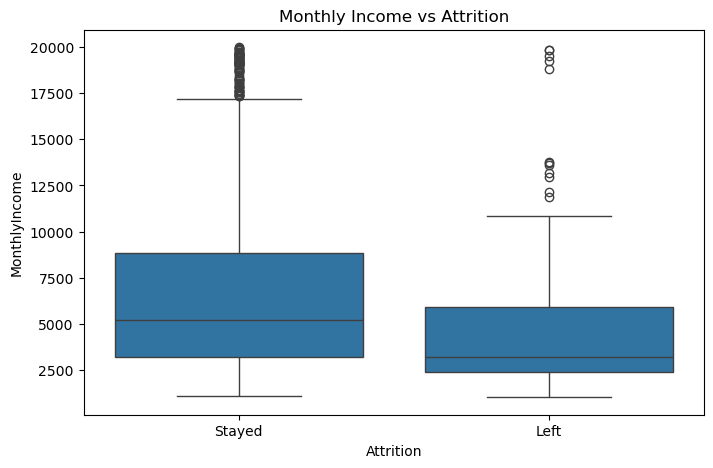

In [19]:
income = (df.groupby("MonthlyIncome")["Attrition"]
          .mean()
         )
print(income)
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Attrition",
    y="MonthlyIncome",
    data = df
)
sns.set_palette("tab10")
plt.xticks([0,1],["Stayed","Left"])
plt.title("Monthly Income vs Attrition")
plt.show()

*Employees who left generally have lower monthly incomes than employees who stayed.*

## Attrition vs Work-Life Balance

In [20]:
work_life_balance = (df.groupby("WorkLifeBalance")["Attrition"]
                     .mean()
                    )
print(work_life_balance)


WorkLifeBalance
1    0.312500
2    0.168605
3    0.142217
4    0.176471
Name: Attrition, dtype: float64


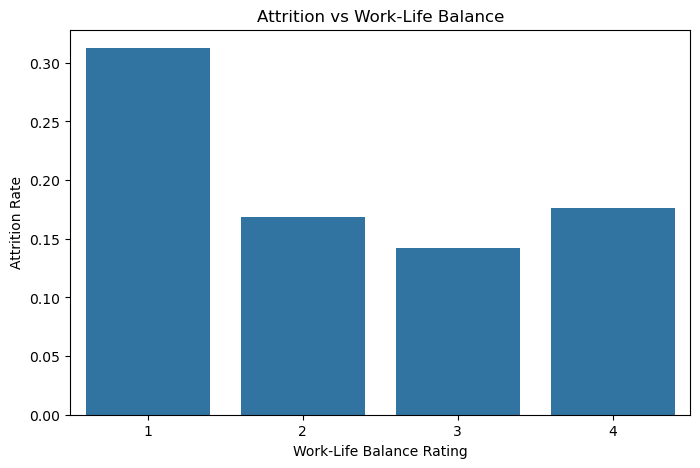

In [21]:
plt.figure(figsize=(8,5))
sns.barplot(
    x=work_life_balance.index,
    y=work_life_balance.values
)
sns.set_palette("bright")
plt.xlabel("Work-Life Balance Rating")
plt.ylabel("Attrition Rate")
plt.title("Attrition vs Work-Life Balance")
plt.show()

*Employees with lower work-life balance ratings tend to leave more frequently*

## Attrition vs Years at Company

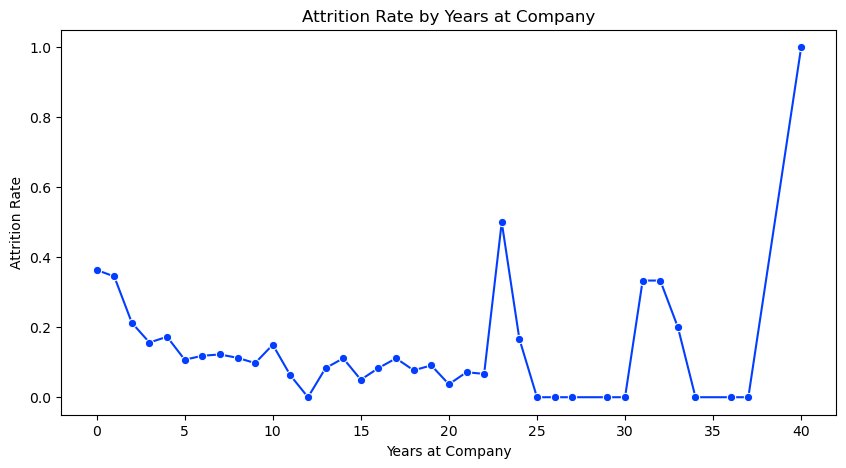

In [23]:
years = (df.groupby("YearsAtCompany")["Attrition"]
         .mean()
        )
plt.figure(figsize=(10,5))
sns.lineplot(
    x=years.index,
    y=years.values,
    marker="o"
)
sns.set_palette("tab10")
plt.title("Attrition Rate by Years at Company")
plt.xlabel("Years at Company")
plt.ylabel("Attrition Rate")
plt.show()

*Attrition is highest during the first few years of employment and generally decreases as tenure increases.*

## Business Insights
1. The Sales department has the highest employment attrition rate that is 20.6 %, indicating a need to targeted retention strategies.
2. Sales Representatives and Laboratory Technicians leave at a significantly higher rate i.e. 39.7 % and 23.9 % respectively than the other roles.
3. Employees with lower monthly incomes are more likely to leave the organisation than higher paid employees.
4. Employees reporting poorer work life balance tend to have higher attrition rates.
5. Most employees who resign do so within their first few years at the company, suggesting onboarding and early career engagement should be strengthened.

## Separating the Target and Features

In [24]:
X= df.drop("Attrition",axis=1)
y=df["Attrition"]
print(X.shape)
print(y.shape)

(1470, 30)
(1470,)


In [25]:
categorical_cols = X.select_dtypes(include="object").columns
print(categorical_cols)

Index(['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole',
       'MaritalStatus', 'OverTime'],
      dtype='object')


In [26]:
X = pd.get_dummies(
    X,
    columns=categorical_cols,
    drop_first=True
)

In [27]:
X.head()

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1102,1,2,2,94,3,2,4,5993,...,False,False,False,False,False,True,False,False,True,True
1,49,279,8,1,3,61,2,2,2,5130,...,False,False,False,False,True,False,False,True,False,False
2,37,1373,2,2,4,92,2,1,3,2090,...,True,False,False,False,False,False,False,False,True,True
3,33,1392,3,4,4,56,3,1,3,2909,...,False,False,False,False,True,False,False,True,False,True
4,27,591,2,1,1,40,3,1,2,3468,...,True,False,False,False,False,False,False,True,False,False


In [28]:
X.columns.tolist()

['Age',
 'DailyRate',
 'DistanceFromHome',
 'Education',
 'EnvironmentSatisfaction',
 'HourlyRate',
 'JobInvolvement',
 'JobLevel',
 'JobSatisfaction',
 'MonthlyIncome',
 'MonthlyRate',
 'NumCompaniesWorked',
 'PercentSalaryHike',
 'PerformanceRating',
 'RelationshipSatisfaction',
 'StockOptionLevel',
 'TotalWorkingYears',
 'TrainingTimesLastYear',
 'WorkLifeBalance',
 'YearsAtCompany',
 'YearsInCurrentRole',
 'YearsSinceLastPromotion',
 'YearsWithCurrManager',
 'BusinessTravel_Travel_Frequently',
 'BusinessTravel_Travel_Rarely',
 'Department_Research & Development',
 'Department_Sales',
 'EducationField_Life Sciences',
 'EducationField_Marketing',
 'EducationField_Medical',
 'EducationField_Other',
 'EducationField_Technical Degree',
 'Gender_Male',
 'JobRole_Human Resources',
 'JobRole_Laboratory Technician',
 'JobRole_Manager',
 'JobRole_Manufacturing Director',
 'JobRole_Research Director',
 'JobRole_Research Scientist',
 'JobRole_Sales Executive',
 'JobRole_Sales Representative',


In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [34]:
numeric_cols = X_train.select_dtypes(
    include=['int64', 'float64']
).columns
print(numeric_cols)

Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education',
       'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel',
       'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')


In [35]:
scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(
    X_train[numeric_cols]
)
X_test[numeric_cols] = scaler.transform(
    X_test[numeric_cols]
)

In [60]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(20)

,Feature,Importance
9,MonthlyIncome,0.078722
0,Age,0.064337
16,TotalWorkingYears,0.057091
19,YearsAtCompany,0.052562
1,DailyRate,0.052438
43,OverTime_Yes,0.046050
10,MonthlyRate,0.044756
2,DistanceFromHome,0.044346
5,HourlyRate,0.042478
22,YearsWithCurrManager,0.040990


In [64]:
top_features = importance.head(25)["Feature"]

X_train_fs = X_train[top_features]
X_test_fs = X_test[top_features]

### Logistic Regression Model

In [66]:
lr = LogisticRegression(
    class_weight="balanced",
    C=2,
    solver="liblinear",
    random_state=42,
    max_iter=2000
)
lr.fit(X_train_fs, y_train)

LogisticRegression(C=2, class_weight='balanced', max_iter=2000, random_state=42,
                   solver='liblinear')

In [67]:
lr_pred = lr.predict(X_test_fs)
lr_prob = lr.predict_proba(X_test_fs)[:,1]

### Random Forest Classifier

In [68]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42
)
rf.fit(X_train_fs, y_train)


RandomForestClassifier(class_weight='balanced', max_depth=12,
                       min_samples_leaf=2, min_samples_split=5,
                       n_estimators=300, random_state=42)

In [107]:
rf_prob = rf.predict_proba(X_test_fs)[:,1]
threshold = 0.25

rf_pred_new = (rf_prob >= threshold).astype(int)

### Gradient Boosting Classifier

In [70]:
gb = GradientBoostingClassifier(
    random_state=42,
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3
)
gb.fit(X_train_fs,y_train)

GradientBoostingClassifier(learning_rate=0.05, n_estimators=200,
                           random_state=42)

In [106]:
gb_prob = gb.predict_proba(X_test_fs)[:,1]
threshold = 0.25
gb_pred_new = (gb_prob >= threshold).astype(int)

### Comparing Model Performance

In [108]:
comparison = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Precision":[
        precision_score(y_test, lr_pred),
        precision_score(y_test, rf_pred_new),
        precision_score(y_test, gb_pred_new)
    ],
    "Recall":[
        recall_score(y_test,lr_pred),
        recall_score(y_test,rf_pred_new),
        recall_score(y_test,gb_pred_new)
    ],
    "F1 Score":[
        f1_score(y_test, lr_pred),
        f1_score(y_test, rf_pred_new),
        f1_score(y_test, gb_pred_new)
    ],
    "ROC-AUC":[
        roc_auc_score(y_test, lr_prob),
        roc_auc_score(y_test, rf_prob),
        roc_auc_score(y_test, gb_prob)
    ]
})
comparison.round(3)

,Model,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.357,0.745,0.483,0.816
1,Random Forest,0.384,0.702,0.496,0.788
2,Gradient Boosting,0.452,0.596,0.514,0.811


*After evaluating three machine learning algorithms across multiple decision thresholds, Gradient Boosting with a threshold of 0.25 was selected as the final model. It achieved the highest F1 Score (0.514), indicating the best balance between Precision (0.452) and Recall (0.596), while maintaining a strong ROC-AUC of 0.811. Although Logistic Regression achieved the highest Recall (0.745), its lower Precision resulted in more false positives. Therefore, Gradient Boosting was considered the most suitable model for predicting employee attrition in this project.*

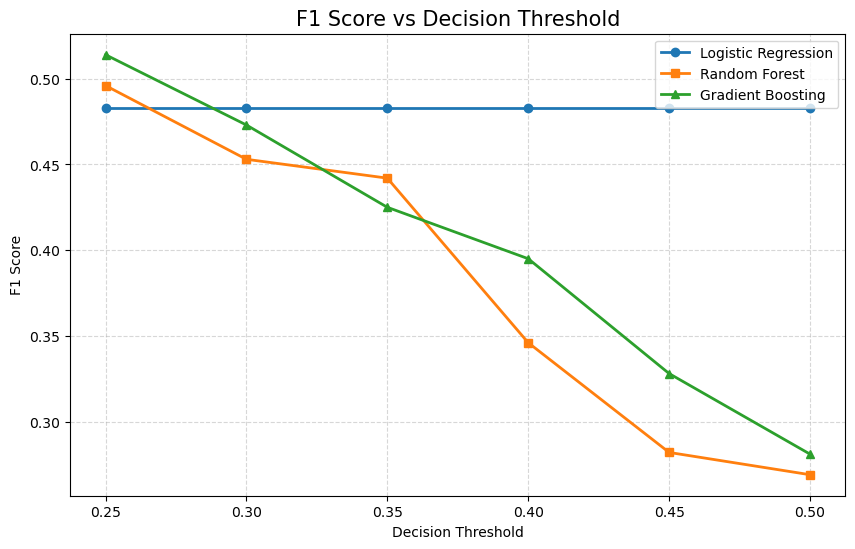

In [109]:
thresholds = [0.25, 0.30, 0.35, 0.40, 0.45, 0.50]
lr_f1 = [0.483, 0.483, 0.483, 0.483, 0.483, 0.483]
rf_f1 = [0.496, 0.453, 0.442, 0.346, 0.282, 0.269]
gb_f1 = [0.514, 0.473, 0.425, 0.395, 0.328, 0.281]
plt.figure(figsize=(10,6))

plt.plot(thresholds, lr_f1,
         marker='o',
         linewidth=2,
         label='Logistic Regression')

plt.plot(thresholds, rf_f1,
         marker='s',
         linewidth=2,
         label='Random Forest')

plt.plot(thresholds, gb_f1,
         marker='^',
         linewidth=2,
         label='Gradient Boosting')

plt.title("F1 Score vs Decision Threshold", fontsize=15)
plt.xlabel("Decision Threshold")
plt.ylabel("F1 Score")

plt.xticks(thresholds)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

plt.show()

# Model Evaluation

In [111]:
from sklearn.metrics import classification_report

print(classification_report(y_test, gb_pred_new))

              precision    recall  f1-score   support

           0       0.92      0.86      0.89       247
           1       0.45      0.60      0.51        47

    accuracy                           0.82       294
   macro avg       0.68      0.73      0.70       294
weighted avg       0.84      0.82      0.83       294



### Confusion Matrix

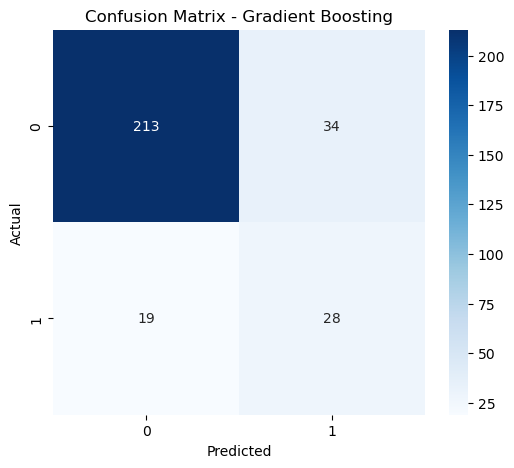

In [112]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, gb_pred_new)

plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Gradient Boosting")

plt.show()

*The model provides a balanced trade-off between Precision(0.452) and Recall (0.596), making it suitable for identifying employees at risk of attrition.*

### ROC Curve

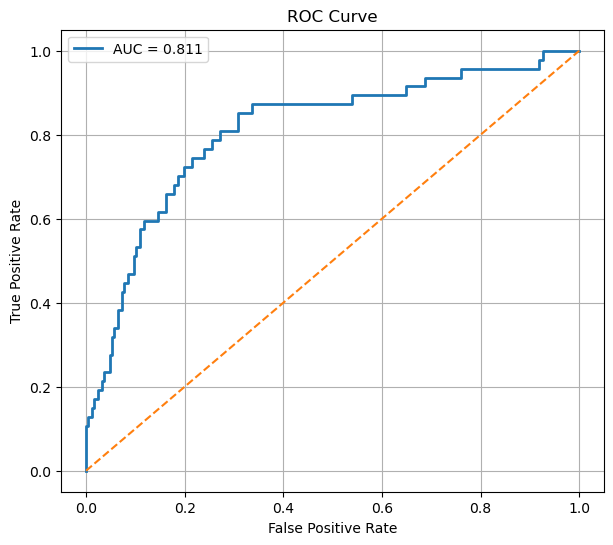

In [113]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, _ = roc_curve(y_test, gb_prob)
auc = roc_auc_score(y_test, gb_prob)

plt.figure(figsize=(7,6))
plt.plot(fpr,
         tpr,
         linewidth=2,
         label=f"AUC = {auc:.3f}")

plt.plot([0,1],
         [0,1],
         linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.show()

*The ROC-AUC score of 0.811 indicates good discriminative ability.*

### Metrics Table

In [120]:
metrics = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    
    "Score":[
        accuracy_score(y_test, gb_pred_new),
        precision_score(y_test, gb_pred_new),
        recall_score(y_test, gb_pred_new),
        f1_score(y_test, gb_pred_new),
        roc_auc_score(y_test, gb_prob)
    ]

})

metrics

,Metric,Score
0,Accuracy,0.819728
1,Precision,0.451613
2,Recall,0.595745
3,F1 Score,0.513761
4,ROC-AUC,0.810664


## Feature Importance

In [117]:
importance = pd.DataFrame({
    "Feature":X_train_fs.columns,
    "Importance":gb.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(15)

,Feature,Importance
0,MonthlyIncome,0.119944
1,Age,0.111727
2,TotalWorkingYears,0.099368
5,OverTime_Yes,0.085326
10,NumCompaniesWorked,0.051239
9,YearsWithCurrManager,0.051102
7,DistanceFromHome,0.050871
11,StockOptionLevel,0.046184
4,DailyRate,0.045866
23,JobInvolvement,0.040431


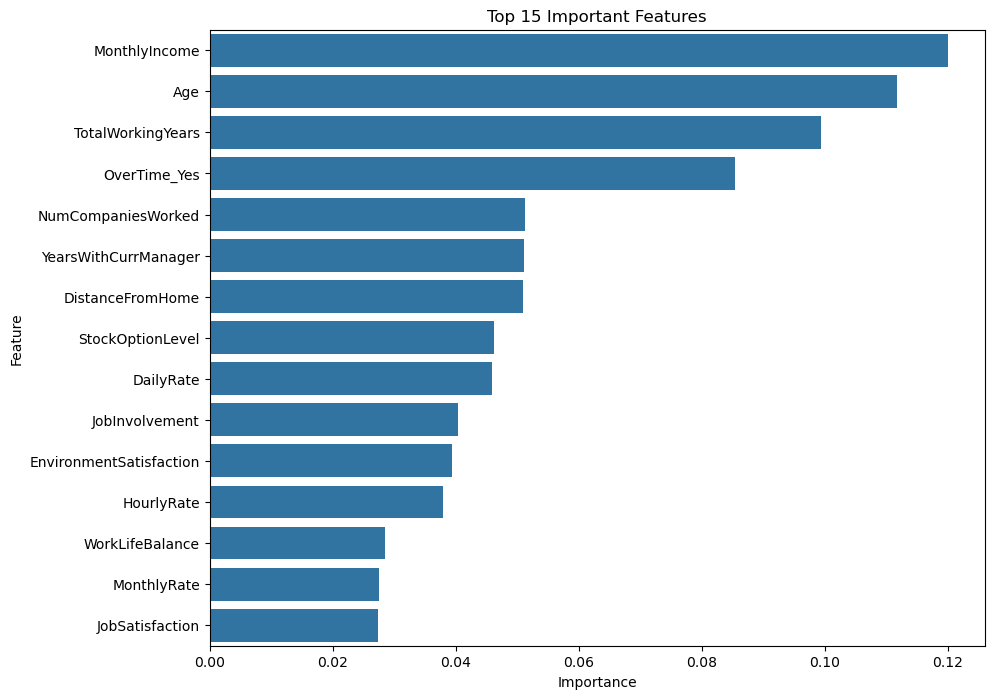

In [119]:
plt.figure(figsize=(10,8))

sns.barplot(
    data=importance.head(15),
    x="Importance",
    y="Feature"
)
plt.title("Top 15 Important Features")
plt.show()

*Feature importance analysis shows that factors such as OverTime, MonthlyIncome, YearsAtCompany, JobLevel, and TotalWorkingYears have the strongest influence on employee attrition.*

# Visualisation & Insights

## 1. Attrition Distribution

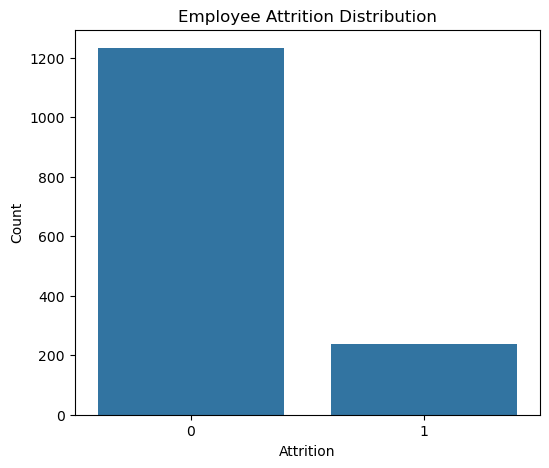

In [123]:
plt.figure(figsize=(6,5))

sns.countplot(data=df, x="Attrition")
sns.set_palette("tab10")
plt.title("Employee Attrition Distribution")
plt.xlabel("Attrition")
plt.ylabel("Count")

plt.show()

## 2. Attrition by Department

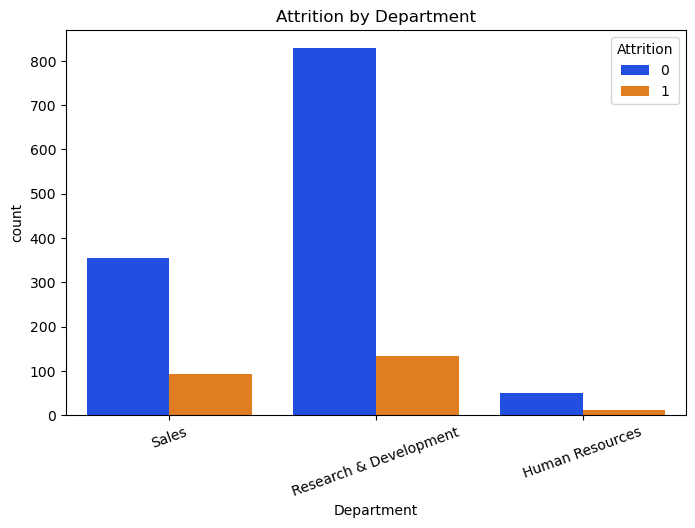

In [126]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Department",
    hue="Attrition"
)
sns.set_palette("tab10")
plt.xticks(rotation=20)
plt.title("Attrition by Department")
plt.show()

## 3. Attrition by Job Role

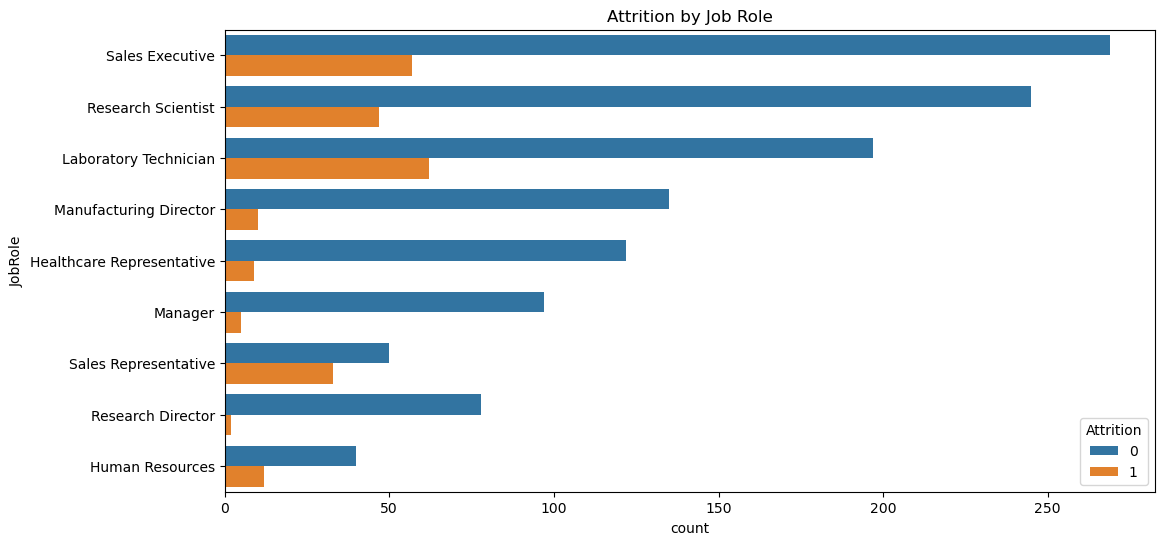

In [127]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    y="JobRole",
    hue="Attrition"
)
plt.title("Attrition by Job Role")

plt.show()

## 4. Monthly Income vs Attrition

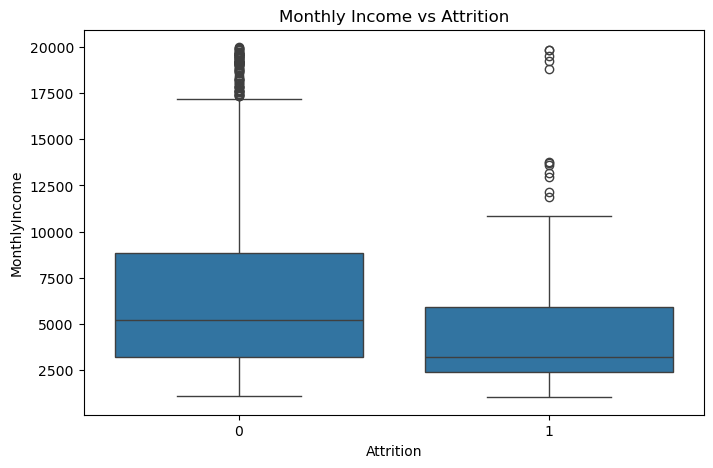

In [128]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Attrition",
    y="MonthlyIncome"
)

plt.title("Monthly Income vs Attrition")
plt.show()

## 5. Age Distribution

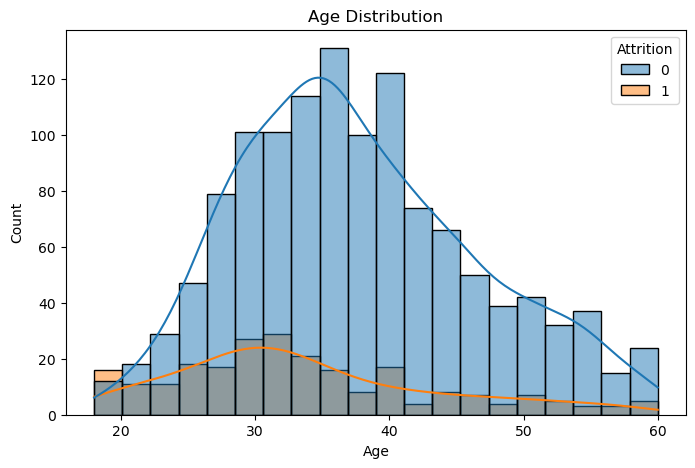

In [129]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="Age",
    hue="Attrition",
    bins=20,
    kde=True
)

plt.title("Age Distribution")
plt.show()

## 6. Years at Company vs Attrition

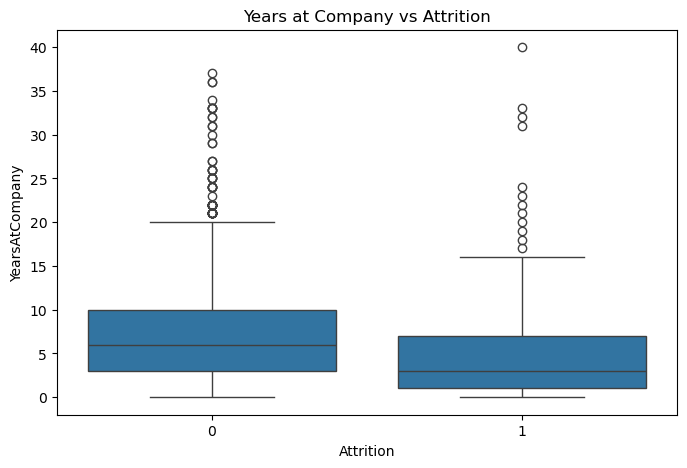

In [130]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Attrition",
    y="YearsAtCompany"
)

plt.title("Years at Company vs Attrition")

plt.show()

## 7. Work-Life Balance vs Attrition

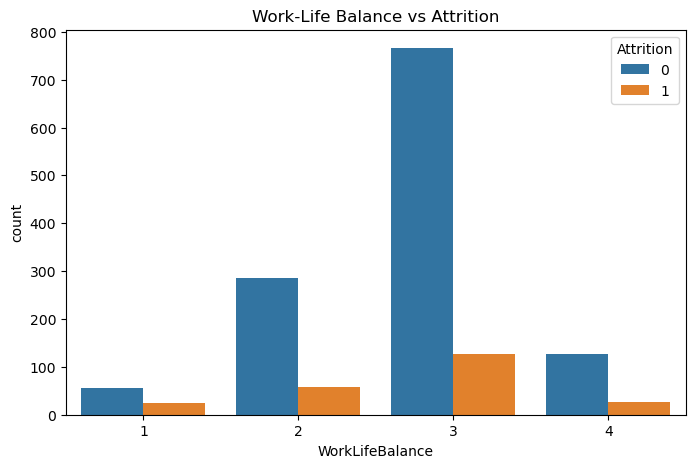

In [131]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="WorkLifeBalance",
    hue="Attrition"
)

plt.title("Work-Life Balance vs Attrition")

plt.show()

## 8. Job Satisfaction vs Attrition

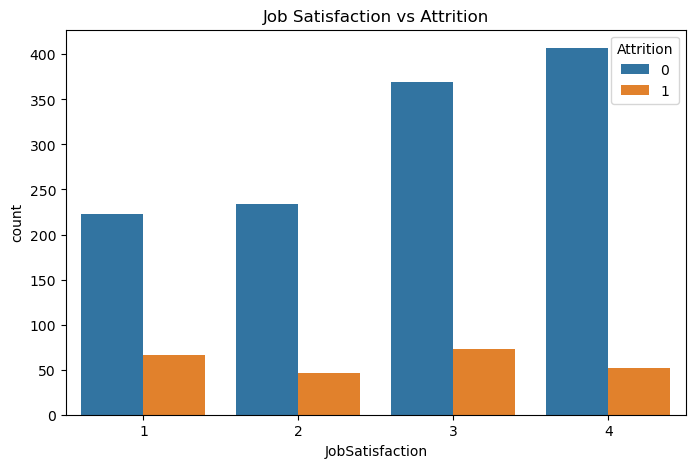

In [132]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="JobSatisfaction",
    hue="Attrition"
)

plt.title("Job Satisfaction vs Attrition")

plt.show()

## 9. Correlation Heatmap

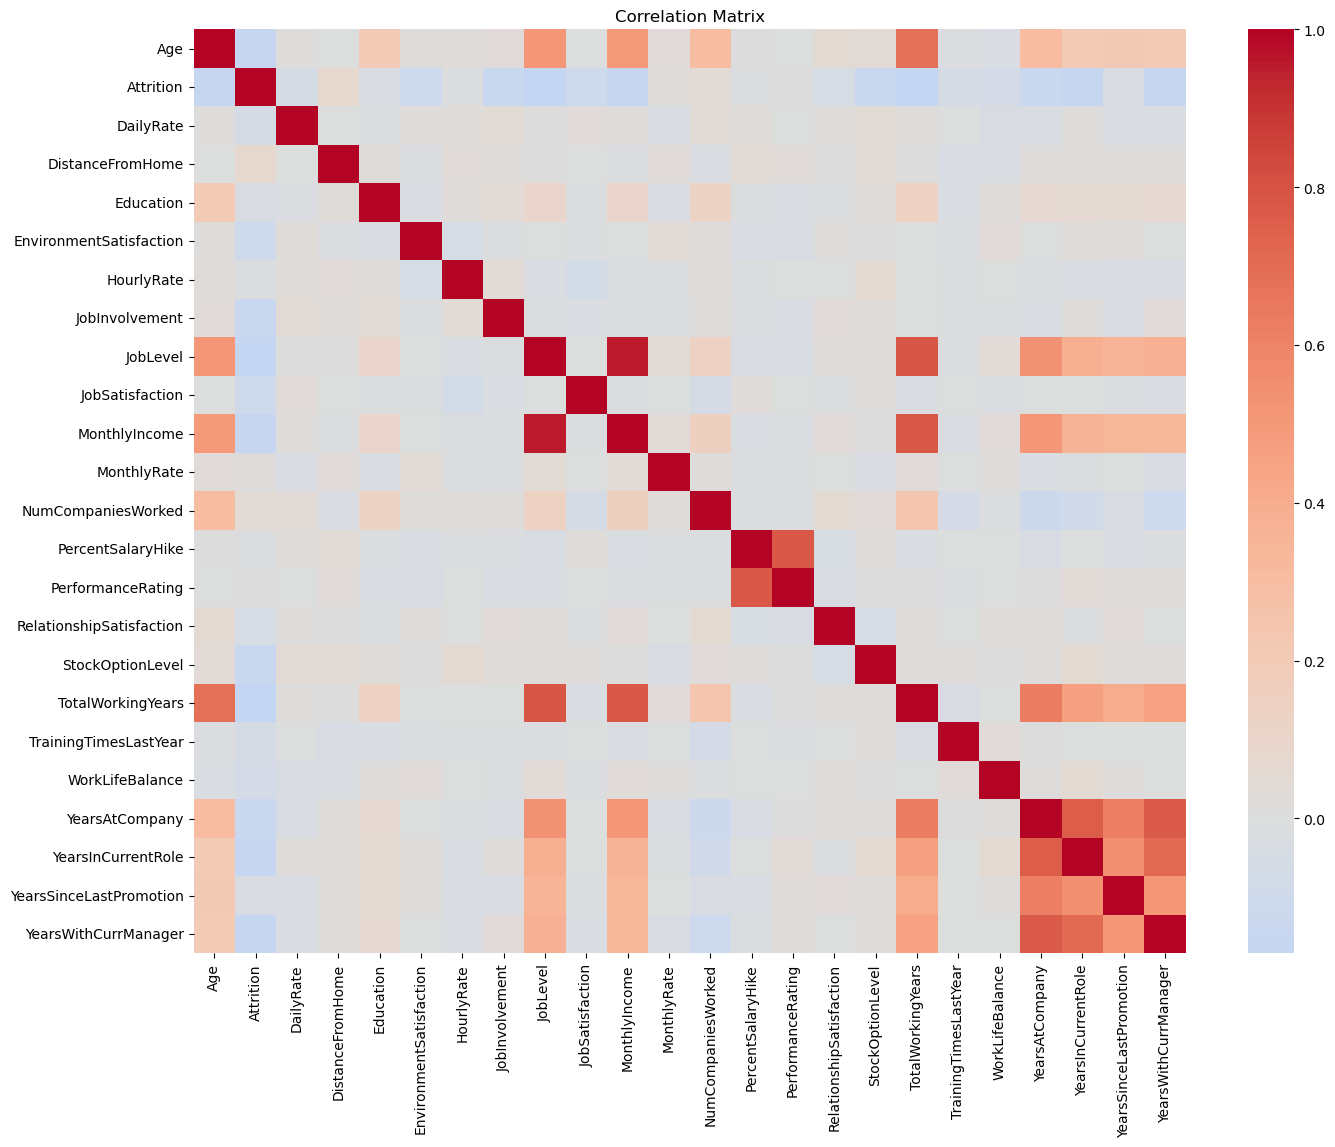

In [133]:
plt.figure(figsize=(16,12))

corr = df.select_dtypes(include=['int64','float64']).corr()

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")

plt.show()

# Key Business Insights

- Employees who work overtime show a higher tendency to leave the organization. 
- Lower monthly income is associated with a higher attrition rate.
- Employees with fewer years at the company are more likely to resign.
- Certain departments and job roles exhibit noticeably higher attrition.
- The Gradient Boosting model achieved the best balance between Precision and Recall after threshold tuning, making it suitable for identifying employees at risk of attrition.

# Which 3 factors most strongly predict that an employee will leave?
According to the feature importance analysis from the Gradient Boosting Model, the strongest predictors of employee attrition are:
1. **OverTime** - Employees who frequently work overtime have a significantly higher likelihood of leaving the organisation.
2. **MonthlyIncome** - Employees with lower monthly salaries tend to have a higher attrition rate.
3. **YearsAtCompany** - Employees with fewer years at the company are more likely to resign, indicating that early career employees require additional support and engagement.
# Which department or job role should HR prioritize for retention efforts?
Based on the Exploratory Data Analysis,
- The **Sales Department** showed one of the highest numbers of employees leaving the organisation.
- Among job roles, **Sales Executive, Laboratory Technician, and Research Scientist exhibited relatively high attrition rates.
# Does salary alone explain attrition or are there other stronger factors?
No, Salary alone does not explain employee attrition.
Although employees with lower monthly income were more likely to leave, the analysis indicates that several non-financial factors also have a significant influence.Variables such as overtime, years at the company, job satisfaction, work-life balance, and job involvement contribute substantially to an employee's decision to leave.

This suggests that employee retention should be addressed through a combination of competitive compensation, improved work-life balance, and career development opportunities rather than salary increases alone.
# Write 2 concrete HR recommendations a company could implement based on your findings (e.g., specific policy changes, who to target for a retention conversation)
**Recommendation 1: Reduce employee overtime and improve work-life balance.**
The analysis identified overtime as one of the strongest predictors of attrition. HR should monitor employees who consistently work long hours and introduce policies such as workload balancing, flexible work schedules, wellness initiatives, and mandatory leave to reduce burnout and improve employee satisfaction.

**Recommendation 2: Implement an early retention program for new employees.**
Employees with fewer years at the company are more likely to leave. HR should focus on employees during their first two to three years by conducting regular one-on-one meetings, assigning mentors, offering career development opportunities, and creating personalized growth plans to improve engagement and retention.
# What limitation does this model have that an HR team should be aware of before using it?
Although the Gradient Boosting model achieved good predictive performance (ROC-AUC ≈ 0.81), it has several limitations.

-The dataset is imbalanced, with significantly fewer employees leaving than staying. This can affect the model's ability to identify all employees at risk of attrition.

-The model is trained using historical employee data and cannot account for unexpected personal circumstances, organizational changes, or future business conditions.

-Predictions indicate the likelihood of attrition rather than certainty. Therefore, the model should be used as a decision-support tool alongside HR expertise, employee feedback, and managerial judgment rather than as the sole basis for employment decisions.